# House Price Prediction — Regression Analysis

**Goal:** Predict house prices from property features (size, rooms, location-related amenities, age-related stories, etc.) and identify which features influence price the most.

This notebook covers data loading, cleaning, model building (Linear Regression & Random Forest), visualization, and a short summary of insights.

## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [2]:
# Shape of the dataset
rows, cols = df.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")

Rows: 545
Columns: 13


**Target column:** `price` — this is the value we want to predict.

**Feature columns:** all remaining 12 columns — `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, `furnishingstatus`. These describe the size, layout, amenities, and condition of each property and are used to predict `price`.

In [3]:
# Column data types
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [4]:
# Check for missing values in each column
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

**Observation:** the dataset has no missing values in any column, so no rows/columns need to be dropped for missingness. We still include a general-purpose missing-value handling step below in case this changes (e.g. if new data is appended later).

## Task 2 — Data Cleaning

Steps performed:
1. Handle missing values (numeric columns → median, categorical columns → mode) — included as a safety net even though this dataset has none.
2. Remove duplicate rows.
3. Convert categorical yes/no columns and `furnishingstatus` into numeric form (binary mapping + one-hot encoding).
4. Keep only columns meaningful for predicting price (drop none here — all 12 features are relevant property attributes).

In [5]:
# 1. Handle missing values (defensive, dataset has none currently)
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

for c in numeric_cols:
    df[c] = df[c].fillna(df[c].median())
for c in categorical_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


In [6]:
# 2. Remove duplicate rows
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Duplicate rows removed: {before - after}")
print(f"Rows remaining: {after}")

Duplicate rows removed: 0
Rows remaining: 545


In [7]:
# 3. Convert yes/no categorical columns into numeric (1/0)
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for c in binary_cols:
    df[c] = df[c].map({'yes': 1, 'no': 0})

# One-hot encode the multi-category 'furnishingstatus' column
df_clean = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

df_clean.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


All 12 original features are kept — each describes a meaningful property attribute (size, rooms, amenities, location desirability, furnishing) that plausibly affects price, so no columns were dropped beyond the encoding transformation above.

## Task 3 — Model Building

We split the cleaned data 80/20 into training and test sets, then train two regression models:
1. **Linear Regression** — a simple, interpretable baseline.
2. **Random Forest Regressor** — a non-linear ensemble model that can capture more complex relationships.

Both are evaluated with MAE, RMSE, and R² Score on the held-out test set.

In [8]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('price', axis=1)
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")

Training rows: 436
Test rows: 109


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Performance")
print(f"  MAE:  {lr_mae:,.0f}")
print(f"  RMSE: {lr_rmse:,.0f}")
print(f"  R^2:  {lr_r2:.3f}")

Linear Regression Performance
  MAE:  970,043
  RMSE: 1,324,507
  R^2:  0.653


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Performance")
print(f"  MAE:  {rf_mae:,.0f}")
print(f"  RMSE: {rf_rmse:,.0f}")
print(f"  R^2:  {rf_r2:.3f}")

Random Forest Performance
  MAE:  1,014,947
  RMSE: 1,399,769
  R^2:  0.612


In [11]:
# Side-by-side comparison
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


**Result:** Linear Regression performs slightly better than Random Forest on this dataset (higher R², lower error), suggesting the relationship between these features and price is largely linear/additive, and the dataset is small enough that Random Forest doesn't have a strong advantage here.

## Task 4 — Visualization

Three charts are created and saved to the `charts/` folder:
1. Histogram of house price distribution.
2. Correlation heatmap of all numeric features vs. price.
3. Actual vs. Predicted price scatter plot (Linear Regression) — a creative choice that visually shows model accuracy.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("charts", exist_ok=True)
sns.set_style("whitegrid")

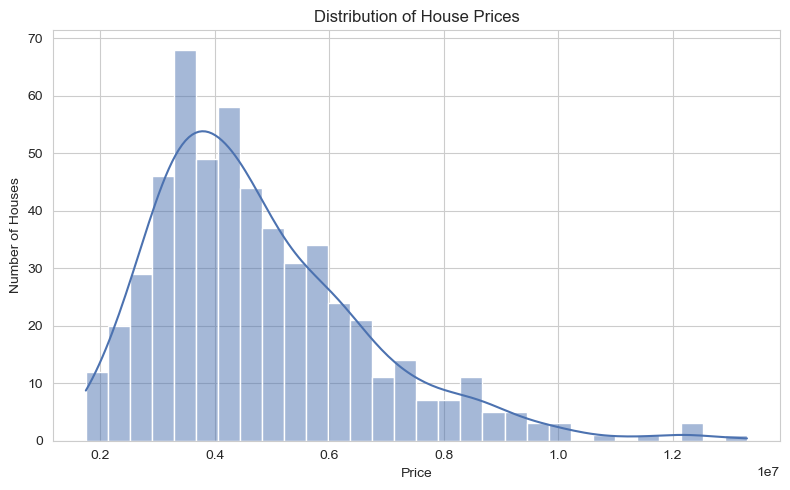

In [13]:
# Chart 1: Histogram of house price distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['price'], bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.savefig("charts/chart1_price_distribution.png", dpi=150)
plt.show()

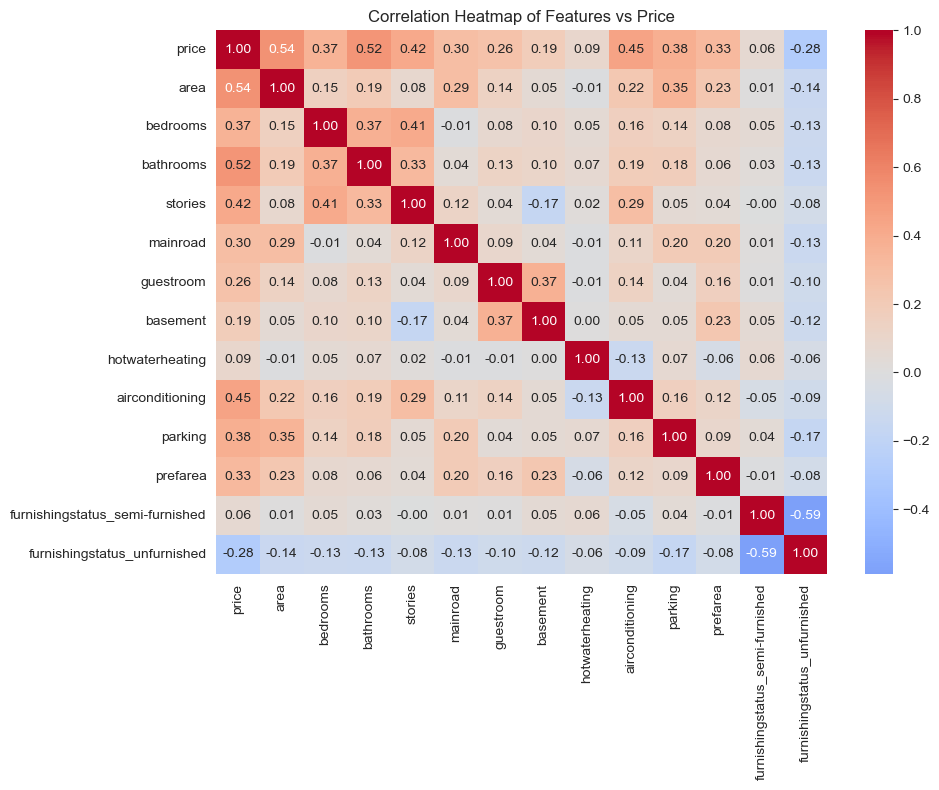

In [14]:
# Chart 2: Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Features vs Price")
plt.tight_layout()
plt.savefig("charts/chart2_correlation_heatmap.png", dpi=150)
plt.show()

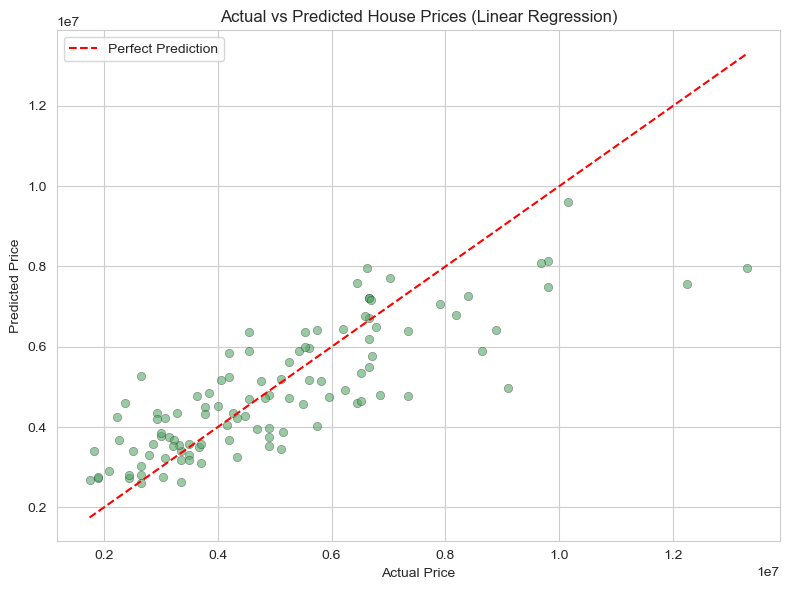

In [15]:
# Chart 3 (creative choice): Actual vs Predicted price scatter plot (Linear Regression)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_preds, alpha=0.6, color="#55A868", edgecolor="k", linewidth=0.3)
min_val, max_val = y_test.min(), y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices (Linear Regression)")
plt.legend()
plt.tight_layout()
plt.savefig("charts/chart3_actual_vs_predicted.png", dpi=150)
plt.show()

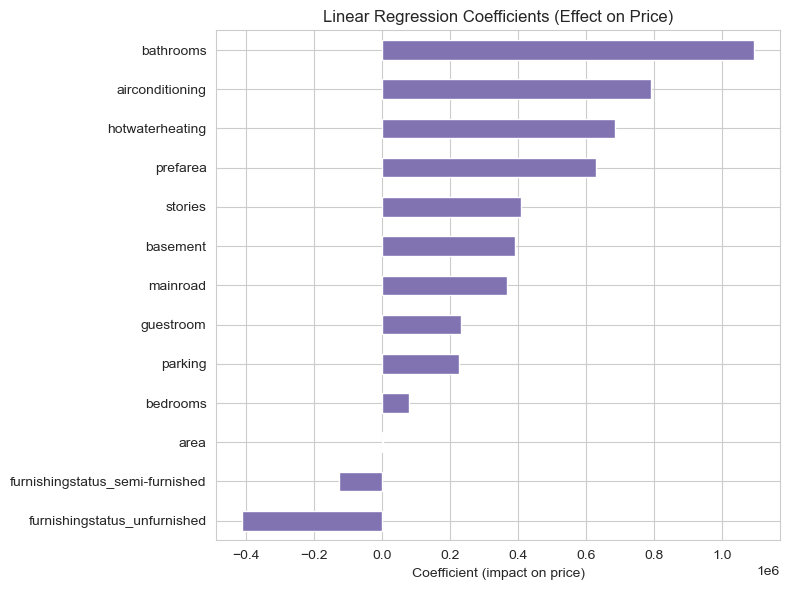

Random Forest Feature Importances:


area                               0.467809
bathrooms                          0.152635
airconditioning                    0.060260
parking                            0.057557
stories                            0.057045
bedrooms                           0.047544
furnishingstatus_unfurnished       0.036974
basement                           0.032418
prefarea                           0.028316
hotwaterheating                    0.018333
guestroom                          0.017916
furnishingstatus_semi-furnished    0.013178
mainroad                           0.010015
dtype: float64

In [16]:
# Feature importance / influence view (supports the insights below)
coef_series = pd.Series(lr_model.coef_, index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
coef_series.plot(kind="barh", color="#8172B2")
plt.title("Linear Regression Coefficients (Effect on Price)")
plt.xlabel("Coefficient (impact on price)")
plt.tight_layout()
plt.show()

rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Random Forest Feature Importances:")
rf_importance

## Task 5 — Insights & Summary

**Which features influence house price the most?** Across both models, **area (square footage)** is consistently the strongest driver of price — it dominates the Random Forest importance ranking and has a large, positive coefficient in Linear Regression. **Number of bathrooms**, having **air conditioning**, **hot water heating**, being in a **preferred area**, and the number of **stories** also push price up noticeably. **Furnishing status** matters too: unfurnished homes sell for clearly less than furnished ones, all else equal.

**How accurate was the model, in plain terms?** The Linear Regression model explains roughly **65% of the variation** in house prices (R² ≈ 0.65), with a typical prediction error (MAE) of under 1 million in the currency unit used — useful for ballpark estimates but not precise enough to set an exact listing price. Random Forest performed slightly worse on this dataset, indicating the relationships here are fairly linear and the dataset is small enough that a simpler model generalizes better.

**What surprised us in the data?** Bedrooms had a surprisingly small effect on price compared to bathrooms and area — buyers in this dataset appear to value usable space and amenities (like air conditioning and hot water heating) more than raw bedroom count. Furnishing status also had a bigger swing than expected, with unfurnished homes priced meaningfully lower.

**Recommendation for a real estate business:** Since area, bathrooms, air conditioning, and location desirability (`prefarea`) drive price the most, agents should prioritize highlighting these features in listings and pricing guidance, and consider that simple cosmetic upgrades (adding AC, furnishing a unit before sale) may yield a disproportionately positive return relative to their cost.